In [1]:
import runBBN
import matplotlib.pyplot as plt

In [2]:
runBBN.run_alterbbn()

	 Yp		 H2/H		 He3/H		 Li7/H		 Li6/H		 Be7/H
 cent:	 2.475e-01	 2.474e-05	 1.035e-05	 5.344e-10	 1.091e-14	 5.055e-10



In [3]:
data = runBBN.read_bbn_output()

Index(['t (s)', 'a', 'T (GK)', 'Tnu (GK)', 'photons', 'f', 'Y(3He)', 'Y(3H)',
       'Y(n)', 'Y(p)', 'Y(2H)', 'Y(4He)', 'Y(7Li)', 'eta'],
      dtype='object')


In [4]:
data

,t (s),a,T (GK),Tnu (GK),photons,f,Y(3He),Y(3H),Y(n),Y(p),Y(2H),Y(4He),Y(7Li),eta
0,1.625160e-11,8.000000e-11,27.000000,27.000000,0.0,66943.6,6.914570e-27,8.156430e-25,3.644970e-01,0.635503,1.011510e-12,6.913140e-31,6.903300e-31,1.672060e-09
1,2.264800e-11,8.000000e-11,27.000000,27.000000,0.0,66943.6,9.082590e-27,1.483190e-24,3.644970e-01,0.635503,1.011510e-12,4.405500e-31,4.369170e-31,1.672060e-09
2,2.437170e-11,8.000000e-11,27.000000,27.000000,0.0,66943.6,9.779390e-27,1.941710e-24,3.644970e-01,0.635503,1.011510e-12,2.724260e-31,2.629210e-31,1.672060e-09
3,2.492850e-11,8.000000e-11,27.000000,27.000000,0.0,66943.6,1.004230e-26,2.264270e-24,3.644970e-01,0.635503,1.011510e-12,1.622510e-31,1.406640e-31,1.672060e-09
4,2.513580e-11,8.000000e-11,27.000000,27.000000,0.0,66943.6,1.014870e-26,2.449710e-24,3.644970e-01,0.635503,1.011510e-12,1.070680e-31,7.051940e-32,1.672060e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15734,1.723040e+06,2.985190e-07,0.010126,0.007243,0.0,43472.6,7.732110e-06,5.891660e-08,7.931340e-17,0.752477,1.861750e-05,6.186560e-02,2.179000e-11,6.100000e-10
15735,1.735340e+06,2.995950e-07,0.010090,0.007217,0.0,43475.1,7.732110e-06,5.891530e-08,7.849780e-17,0.752477,1.861750e-05,6.186560e-02,2.179050e-11,6.100000e-10
15736,1.748880e+06,3.007740e-07,0.010051,0.007189,0.0,43478.0,7.732110e-06,5.891380e-08,7.761660e-17,0.752477,1.861750e-05,6.186560e-02,2.179110e-11,6.100000e-10
15737,1.763770e+06,3.020650e-07,0.010008,0.007158,0.0,43481.0,7.732110e-06,5.891230e-08,7.666630e-17,0.752477,1.861750e-05,6.186560e-02,2.179160e-11,6.100000e-10


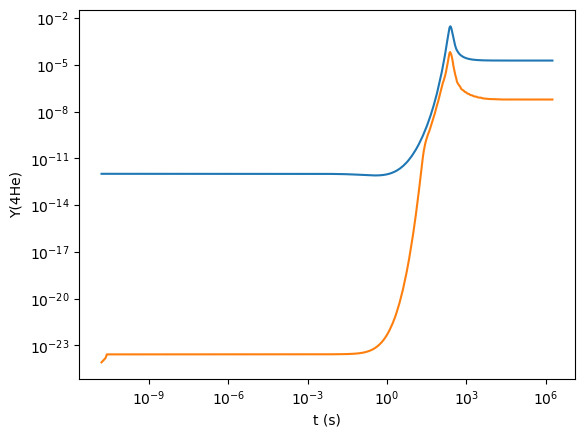

In [6]:
plt.figure()
plt.loglog(data['t (s)'], data['Y(2H)'])
plt.loglog(data['t (s)'], data['Y(3H)'])
plt.xlabel('t (s)')
plt.ylabel('Y(4He)')
plt.show()

In [7]:
import ODESolve_slow as ODE
from constants import mN
import numpy as np
import thermodynamics as thermo
from constants import me, mpl, zeta3, hbar, MeVtoT9, cmgstoMeV
import weakrates as weak
import expansion as ex
import nseabundance as nse
import derivatives as der
import xy_reactions as xy
import xgamma_reactions as xg

In [8]:
def sep(z):
    return z[0], z[1], z[2], z[3:]
T,t,eta,A = sep(np.arange(12))

#creates array of 12 dependent variables
def depvar(T,t,eta,A):
    return np.concatenate((np.array([T,t,eta]), A))

In [9]:
def a_total_y_tot(eta_final):
    
    a0 = 0.1    
    T0 = 10
    t0 = 0
    eta0 = eta_final*(11/4)
    Yp0 = (1+(weak.Npntot(T0,a0))/(weak.Nnptot(T0,a0)) )**(-1)
    Yn0 = 1-Yp0

    y0 = depvar(T0, t0, eta0, nse.nse(T0, eta0, Yp0, Yn0))
    p = 0
    dx0=0.001

    N_step = 1000
    dN = 1

    x_final = 0.4

    a, y, dx, done = ODE.ODEOneRun(a0, y0, dx0, p, N_step, dN, x_final)
    print(done)

    a1 = a[-1]
    T1 = y[-1, 0]
    t1 = y[-1, 1]
    eta1 = y[-1, 2]
    Y1 = der.depvar(T1,t1,eta1,nse.nse(T1,eta1,y[-1,3], y[-1,4]))
    dx1 = dx[-1]*0.001
    p = 2
    Nstep = 1000
    dN = 20
    x_final = 100

    a2, y2, dx2, done = ODE.ODEOneRun(a1, Y1, dx1, p, Nstep, dN, x_final)
    print(done)
    for i in range(len(a)):
        A_nse = nse.nse(y[i,0], y[i,2], y[i,3],y[i,4])
        y[i,3:] = A_nse   

    a_total = np.concatenate((a[:-1],a2))   #creates an array pof all the ind var values
    #len(a_total) = len(a)-1+len(a2)
    y_total = np.concatenate((y[:-1,:],y2),axis = 0) #creates a matrix of dep var values
    #y_total.shape is len(a_total) x 12

    return a_total, y_total

In [10]:
%%time
a_total, y_total  = a_total_y_tot(6.1e-10)
a_total_low, y_total_low = a_total_y_tot(3e-10)
a_total_high, y_total_high = a_total_y_tot(9e-10)

True
True
True
True
True
True
CPU times: user 50.3 s, sys: 1.32 s, total: 51.6 s
Wall time: 50.7 s


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

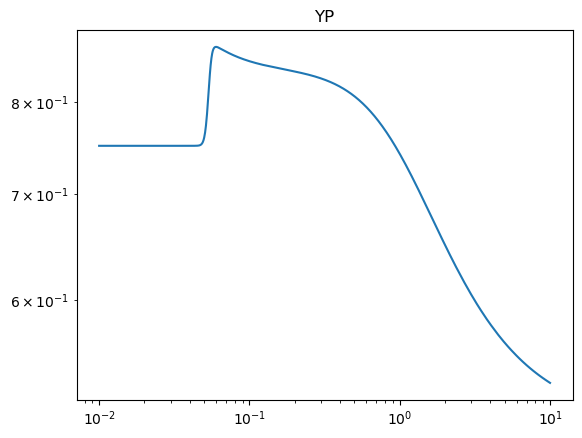

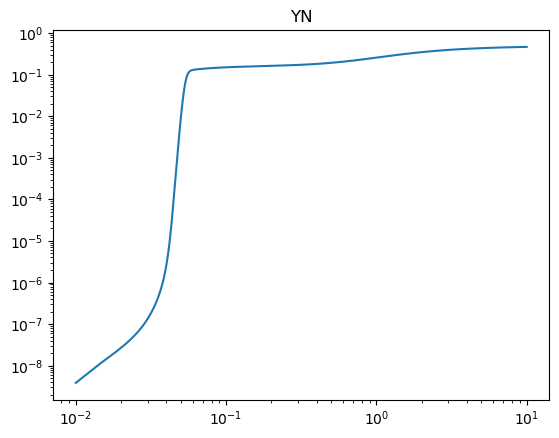

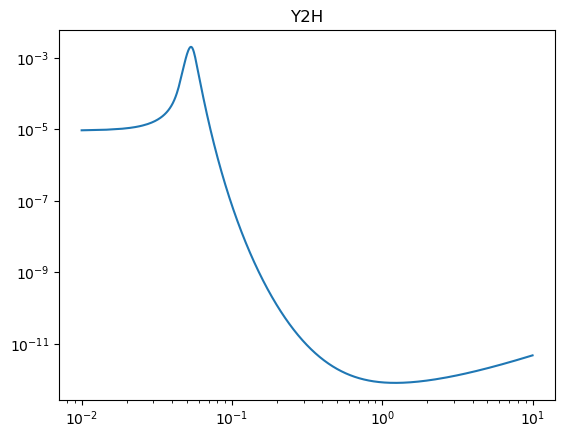

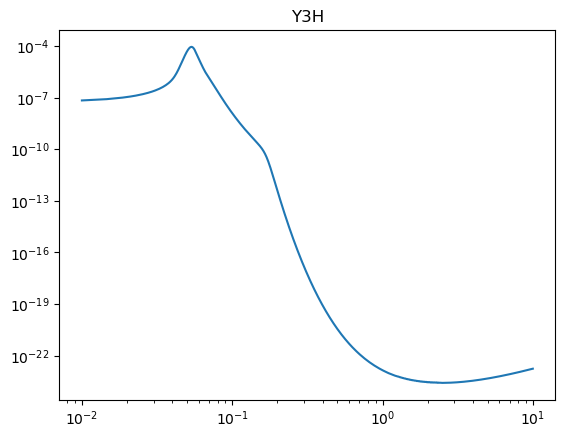

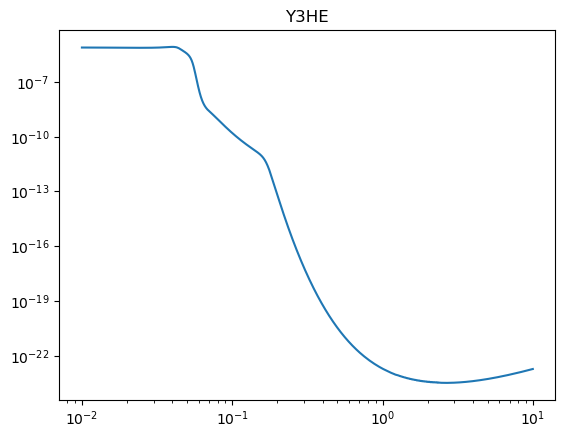

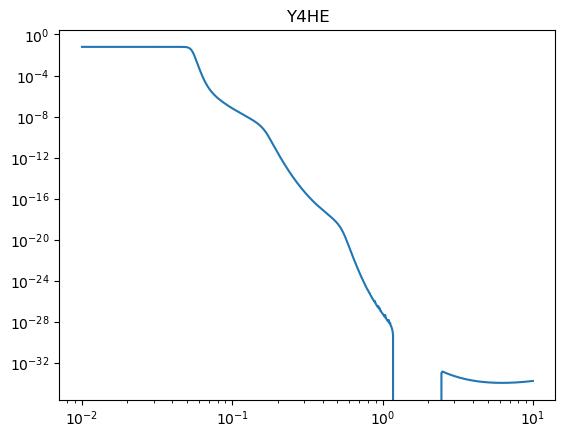

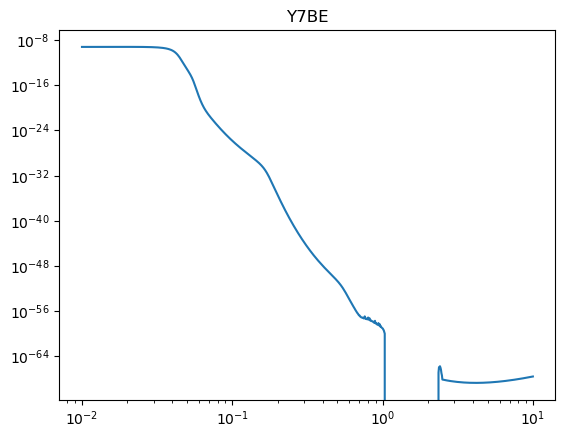

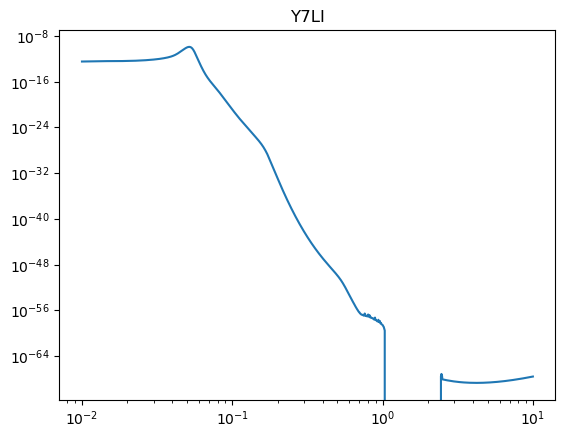

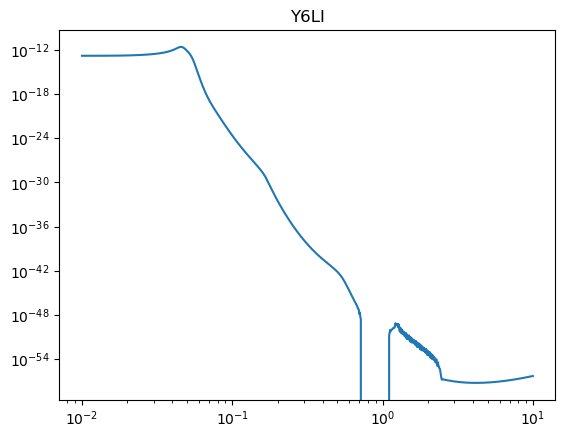

<Figure size 640x480 with 0 Axes>

In [11]:
plt.figure()
Tcm=1/a_total
YP = np.zeros(len(a_total))
YN = np.zeros(len(a_total)) 
Y2H = np.zeros(len(a_total)) 
Y3H = np.zeros(len(a_total)) 
Y3HE = np.zeros(len(a_total)) 
Y4HE = np.zeros(len(a_total)) 
Y7BE = np.zeros(len(a_total)) 
Y7LI = np.zeros(len(a_total)) 
Y6LI = np.zeros(len(a_total)) 
nseval=np.zeros((9,len(a_total)))
    
for i in range(len(a_total)):
    
    YP[i] = y_total[i,3]
    YN[i] = y_total[i,4]
    Y2H[i] = y_total[i,5]
    Y3H[i] = y_total[i,6]
    Y3HE[i] = y_total[i,7]
    Y4HE[i] = y_total[i,8]
    Y7BE[i] = y_total[i,9]
    Y7LI[i] = y_total[i,10]
    Y6LI[i] = y_total[i,11]

    nseval[:,i] = nse.nse(y_total[i,0] , y_total[i,2] , y_total[i,3] , y_total[i,4],)
plt.figure()
plt.loglog(Tcm,YP)
plt.title("YP")
plt.figure()
plt.loglog(Tcm,YN)
plt.title("YN")
plt.figure()
plt.loglog(Tcm,Y2H)
plt.title("Y2H")
plt.figure()
plt.loglog(Tcm,Y3H )
plt.title("Y3H")
plt.figure()
plt.loglog(Tcm,Y3HE )
plt.title("Y3HE")
plt.figure()
plt.loglog(Tcm,Y4HE )
plt.title("Y4HE")
plt.figure()
plt.loglog(Tcm, Y7BE)
plt.title("Y7BE")
plt.figure()
plt.loglog(Tcm,Y7LI )
plt.title("Y7LI")
plt.figure()
plt.loglog(Tcm,Y6LI)
plt.title("Y6LI")
plt.figure()

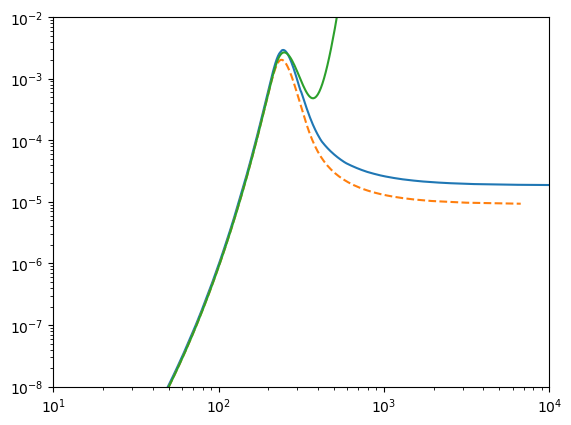

In [12]:
plt.figure()
plt.loglog(data['t (s)'], data['Y(2H)'])
plt.loglog(y_total[:,1] * hbar, y_total[:,3+nse.H2_INDEX], ls='--')
plt.loglog(y_total[:,1] * hbar , nseval[2,:])
plt.xlim(10, 1e4)
plt.ylim(1e-8, 1e-2)

plt.show()

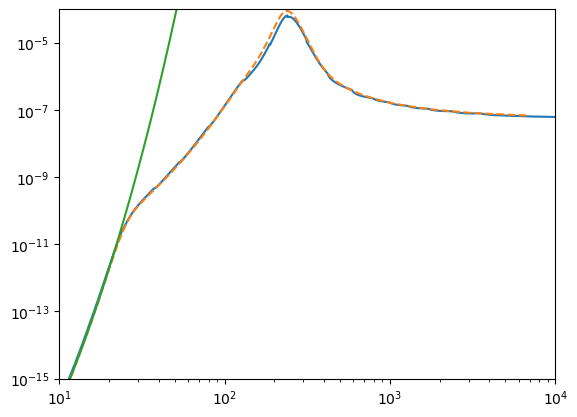

In [13]:
plt.figure()
plt.loglog(data['t (s)'], data['Y(3H)'])
plt.loglog(y_total[:,1] * hbar, y_total[:,3+nse.H3_INDEX], ls='--')
plt.loglog(y_total[:,1] * hbar , nseval[3,:])
plt.xlim(10, 1e4)
plt.ylim(1e-15, 1e-4)
plt.show()

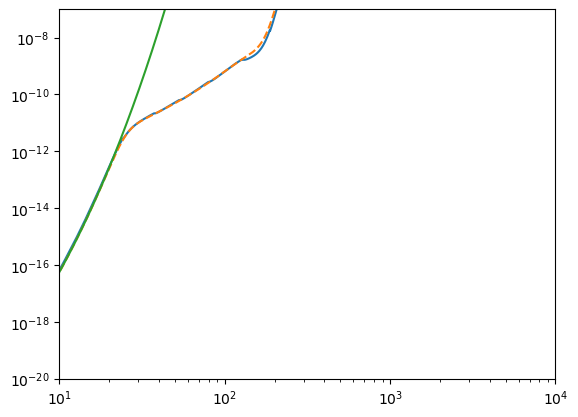

In [14]:
plt.figure()
plt.loglog(data['t (s)'], data['Y(3He)'])
plt.loglog(y_total[:,1] * hbar, y_total[:,3+nse.HE3_INDEX], ls='--')
plt.loglog(y_total[:,1] * hbar , nseval[4,:])
plt.xlim(10, 1e4)
plt.ylim(1e-20, 1e-7)
plt.show()

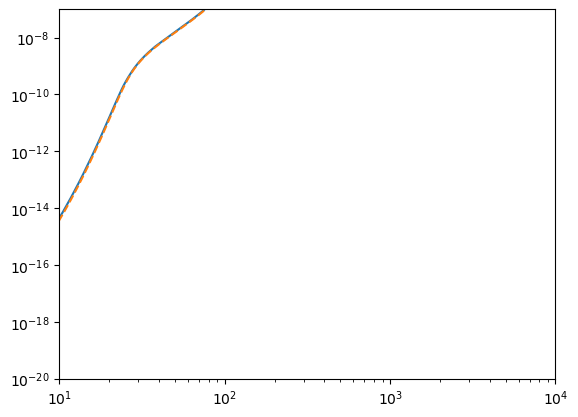

In [15]:
plt.figure()
plt.loglog(data['t (s)'], data['Y(4He)'])
plt.loglog(y_total[:,1] * hbar, y_total[:,3+nse.HE4_INDEX], ls='--')
plt.loglog(y_total[:,1] * hbar , nseval[5,:])
plt.xlim(10, 1e4)
plt.ylim(1e-20, 1e-7)
plt.show()

In [16]:
print(nseval[:,5])

[5.32550522e-01 4.67449478e-01 4.61131652e-12 1.73173797e-23
 1.82747720e-23 1.82583414e-34 2.43408820e-68 2.52296636e-68
 4.42774466e-57]


(10, 10000.0)

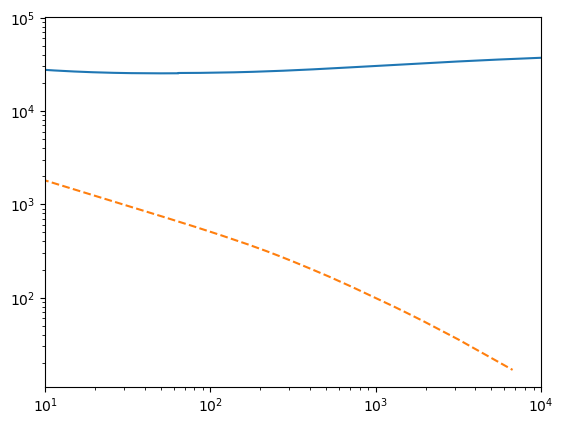

In [17]:
dpghe = np.zeros(len(y_total[:,0]))
for i in range(len(dpghe)):
    dpghe[i] = xg.dpghe3(y_total[i,0]) / cmgstoMeV / mN

plt.loglog(data['t (s)'], data['f'])
plt.loglog(y_total[:,1] * hbar, dpghe, ls='--')
plt.xlim(10, 1e4)

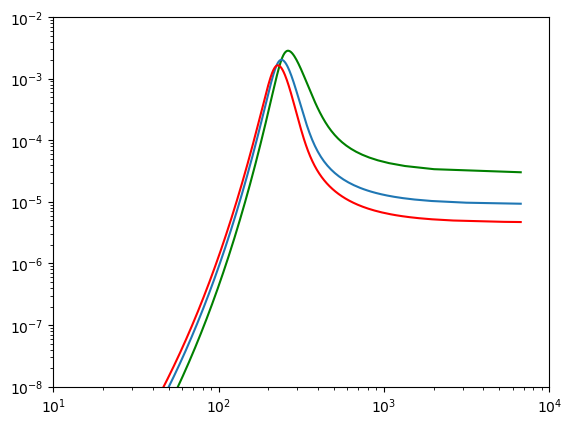

In [18]:
plt.figure()
plt.loglog(y_total_low[:,1] * hbar, y_total_low[:,3+nse.H2_INDEX], color = "green")
plt.loglog(y_total[:,1] * hbar, y_total[:,3+nse.H2_INDEX],)
plt.loglog(y_total_high[:,1] * hbar, y_total_high[:,3+nse.H2_INDEX], color = "red")
plt.xlim(10, 1e4)
plt.ylim(1e-8, 1e-2)

plt.show()

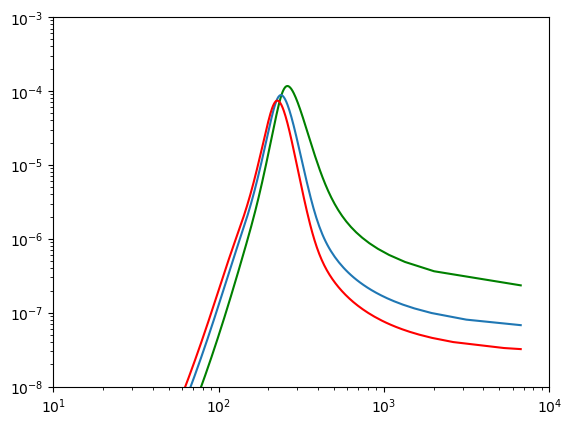

In [19]:
plt.figure()
plt.loglog(y_total_low[:,1] * hbar, y_total_low[:,3+nse.H3_INDEX], color = "green")
plt.loglog(y_total[:,1] * hbar, y_total[:,3+nse.H3_INDEX],)
plt.loglog(y_total_high[:,1] * hbar, y_total_high[:,3+nse.H3_INDEX], color = "red")
plt.xlim(10, 1e4)
plt.ylim(1e-8, 1e-3)

plt.show()

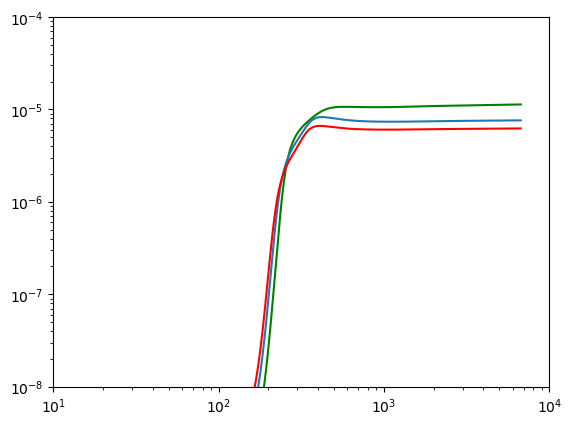

In [20]:
plt.figure()
plt.loglog(y_total_low[:,1] * hbar, y_total_low[:,3+nse.HE3_INDEX], color = "green")
plt.loglog(y_total[:,1] * hbar, y_total[:,3+nse.HE3_INDEX],)
plt.loglog(y_total_high[:,1] * hbar, y_total_high[:,3+nse.HE3_INDEX], color = "red")
plt.xlim(10, 1e4)
plt.ylim(1e-8, 1e-4)

plt.show()

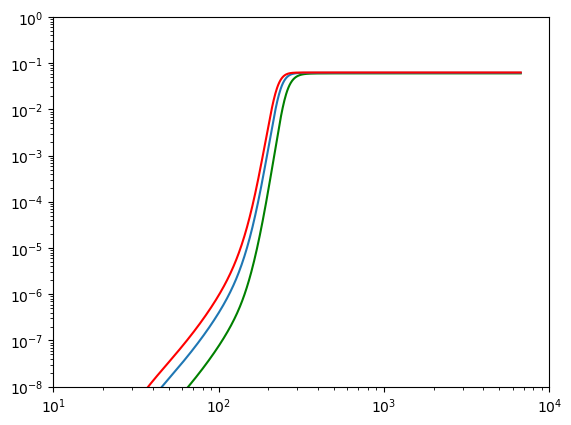

In [21]:
plt.figure()
plt.loglog(y_total_low[:,1] * hbar, y_total_low[:,3+nse.HE4_INDEX], color = "green")
plt.loglog(y_total[:,1] * hbar, y_total[:,3+nse.HE4_INDEX],)
plt.loglog(y_total_high[:,1] * hbar, y_total_high[:,3+nse.HE4_INDEX], color = "red")
plt.xlim(10, 1e4)
plt.ylim(1e-8, 1e-0)

plt.show()

In [22]:
print(y_total[-1,2])


6.101100181347482e-10


In [44]:
np.savez("Q0", a_total = a_total, y_total = y_total)